# Final Group Analysis

In [1]:
import pandas as pd
import os

In [2]:
# Folder path
folder_path = 'groups_data'

# Dictionary to store dataframes
dfs = {}

# Loop through all CSV files in folder
for file in os.listdir(folder_path):
    if file.endswith('.csv'):
        file_path = os.path.join(folder_path, file)
        df_name = file.replace('.csv', '')  # remove .csv for key name
        dfs[df_name] = pd.read_csv(file_path)
        dfs[df_name]["group"] = df_name
        print(f"Imported: {file} - Shape: {dfs[df_name].shape}")

# Access a specific dataframe
# dfs['filename']

Imported: high_spenders.csv - Shape: (261, 25)
Imported: no_bookers.csv - Shape: (508, 25)
Imported: only_flight_bookers.csv - Shape: (94, 25)
Imported: only_hotel_bookers.csv - Shape: (373, 25)
Imported: no_return.csv - Shape: (57, 25)
Imported: uncommon_travelers.csv - Shape: (1654, 25)
Imported: frequent_travelers.csv - Shape: (1607, 25)
Imported: discount_travelers.csv - Shape: (374, 25)
Imported: hotel_favourites.csv - Shape: (542, 25)
Imported: family_travelers.csv - Shape: (312, 25)
Imported: user_perks.csv - Shape: (5782, 3)
Imported: complete_df.csv - Shape: (5782, 26)


In [3]:
df = pd.concat(dfs.values(), ignore_index=True)

In [4]:
df

,user_id,gender,married,has_children,home_country,Age,days_in,trip_session_ratio,no_cancellations,ave_page_clicks,...,hotel_avg_cost_per_r_n,average_rooms,flight_no_bookings,flight_avg_seats,flight_avg_rev,flight_avg_cost_per_seat,ave_rev_per_day,flight_ave_days_stayed,group,perk
0,299476,F,True,False,usa,41.0,1420.0,2.500000,1.0,39.000000,...,601.500000,1.00,2.0,1.500000,2974.310000,1535.250000,12.261000,7.500,high_spenders,NaN
1,338086,F,False,True,usa,42.0,1389.0,2.250000,0.0,16.416667,...,152.250000,1.75,4.0,1.750000,2537.272500,849.735000,8.390994,2.250,high_spenders,NaN
2,347778,F,False,False,usa,51.0,1381.0,1.444444,0.0,22.923077,...,210.587500,1.50,8.0,1.375000,1786.256375,760.931375,18.738632,2.875,high_spenders,NaN
3,359080,F,True,False,usa,44.0,1373.0,1.571429,0.0,18.727273,...,317.750000,1.50,6.0,1.166667,1627.048333,998.490000,12.477269,5.400,high_spenders,NaN
4,373489,F,True,True,usa,39.0,1363.0,4.000000,0.0,14.250000,...,220.000000,1.50,2.0,3.500000,12374.175000,3193.311250,25.123514,11.500,high_spenders,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17341,656422,F,False,False,canada,39.0,1221.0,1.750000,0.0,21.875000,...,172.666667,2.00,4.0,1.750000,1355.850000,807.660000,6.427846,3.000,complete_df,Free Activity
17342,656920,F,True,False,usa,39.0,1221.0,2.000000,0.0,17.750000,...,366.000000,2.00,2.0,2.500000,1747.433000,540.467000,4.061315,3.500,complete_df,Free Activity
17343,664998,F,True,False,usa,51.0,1218.0,4.000000,0.0,11.125000,...,80.000000,3.00,2.0,2.000000,753.513500,351.914500,1.631385,1.500,complete_df,Free Activity
17344,672009,F,True,False,usa,53.0,1215.0,3.500000,0.0,19.625000,...,138.000000,3.00,2.0,3.000000,3539.382750,1179.794250,7.147132,2.500,complete_df,Free Activity


In [5]:
df["group"].value_counts()

group
user_perks             5782
complete_df            5782
uncommon_travelers     1654
frequent_travelers     1607
hotel_favourites        542
no_bookers              508
discount_travelers      374
only_hotel_bookers      373
family_travelers        312
high_spenders           261
only_flight_bookers      94
no_return                57
Name: count, dtype: int64

### only hotel bookers
did only hotel bookers book flights and cancelled?

In [6]:
users = pd.read_csv('preprocessed_data/users_preprocessed.csv')
sessions = pd.read_csv('preprocessed_data/sessions_preprocessed.csv')
hotels = pd.read_csv('preprocessed_data/hotels_preprocessed.csv')
flights = pd.read_csv('preprocessed_data/flights_preprocessed.csv')
invalid_trip_ids = sessions[sessions["cancellation"]]["trip_id"]

In [7]:
user_features = df.copy()

In [8]:
#only the group
no_flight_bookers_uid = user_features[user_features["group"] == "only_hotel_bookers"]["user_id"]

In [9]:
#only the sessions from users in the group -> how often cancelled & how often booked?
sessions[sessions["user_id"].isin(no_flight_bookers_uid)].groupby("user_id").agg({"cancellation": "sum", "flight_booked": "sum"})

,cancellation,flight_booked
user_id,,
258451,1,1
340166,0,0
386469,0,0
395202,0,0
425653,0,0
...,...,...
728820,1,2
739734,0,0
752933,1,1


- Round trips are only part of one trip (trip id in flights is unique)
- if cancelled flight_booked and hotel_booked is 1, even when no flight or hotel was booked.

In [10]:
sessions[sessions["user_id"] == 728820]

,session_id,user_id,trip_id,session_start,session_end,flight_discount_amount,hotel_discount_amount,flight_booked,hotel_booked,page_clicks,cancellation
27056,728820-30f235ba121947658f02a433d818f956,728820,NaN,2023-04-07 14:24:00,2023-04-07 14:24:21,0.150000,NaN,False,False,3,False
27437,728820-11b95bbe24d84d769e685c1b79f92fdf,728820,NaN,2023-04-12 10:06:00,2023-04-12 10:06:38.000000,NaN,NaN,False,False,5,False
27917,728820-dcd82f58f23b479abda2397086cdaefa,728820,NaN,2023-04-18 18:03:00,2023-04-18 18:06:30.000000,NaN,NaN,False,False,28,False
29428,728820-7d123da69098443d969a6eb93bddcdf7,728820,728820-d71ab825a7b544b8ae06179ef3b06607,2023-05-08 18:24:00,2023-05-08 18:27:11.000000,0.100000,NaN,False,True,25,False
32521,728820-6d56f095ea3e42389a0c2b6f15a4c7eb,728820,NaN,2023-06-21 20:49:00,2023-06-21 20:49:52.000000,NaN,NaN,False,False,7,False
33287,728820-1d8b3d07e0ef4276902c7950f2aa1d4e,728820,NaN,2023-07-02 17:23:00,2023-07-02 17:24:53.000000,NaN,NaN,False,False,15,False
33356,728820-23218575ad4b4e178a0d27821c4b5368,728820,728820-51efaf48ca164a92a6aa1b0d40ea8a9f,2023-07-03 18:15:00,2023-07-03 18:17:18.000000,NaN,NaN,True,False,19,False
34795,728820-510a9d362af249f395f781c0daafb341,728820,728820-51efaf48ca164a92a6aa1b0d40ea8a9f,2023-07-08 18:17:18,2023-07-08 20:17:18.000000,0.139553,0.112065,True,True,200,True


In [11]:
sessions.groupby(["flight_booked", "hotel_booked", "cancellation"])["session_id"].count()

flight_booked  hotel_booked  cancellation
False          False         False           31905
               True          False            2397
True           False         False            1790
               True          False           11977
                             True              614
Name: session_id, dtype: int64

when something is cancelled, both - hotel_booked and flight_booked - are marked True

In [12]:
sessions[sessions["user_id"].isin(no_flight_bookers_uid) & ~sessions["cancellation"]].groupby("user_id").agg({"flight_booked": "sum"}).value_counts()

flight_booked
0                338
1                 35
Name: count, dtype: int64

338 have never booked a flight, 35, so roughly 10% booked a flight and cancelled.
Did they didnt book a flight because they were traveling domestically?

In [13]:
users[users["user_id"].isin(no_flight_bookers_uid)]

,user_id,birthdate,gender,married,has_children,home_country,home_city,home_airport,home_airport_lat,home_airport_lon,sign_up_date,Age,days_in
26,340166,1973-05-17,M,True,True,usa,san francisco,SFO,37.619,-122.375,2022-09-27,53,1387
55,386469,2006-10-16,F,False,False,usa,stockton,SCK,37.894,-121.239,2022-10-30,19,1354
84,429345,1958-02-05,M,True,True,usa,tallahassee,TLH,30.396,-84.350,2022-11-23,68,1330
129,458725,2006-09-06,F,False,False,usa,montgomery,MXF,32.379,-86.362,2022-12-09,19,1314
161,471946,1979-04-07,F,True,True,usa,santa ana,SNA,33.676,-117.868,2022-12-16,47,1307
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5747,708887,2001-08-23,F,False,False,usa,rochester,ROC,43.119,-77.672,2023-03-31,24,1202
5755,716801,1956-09-10,F,True,False,usa,sacramento,SAC,38.513,-121.493,2023-04-03,69,1199
5760,721570,1980-03-02,F,False,False,usa,newark,EWR,40.692,-74.169,2023-04-05,46,1197
5763,728820,1985-07-15,M,False,True,usa,houston,HOU,29.645,-95.279,2023-04-07,41,1195


In [14]:
hotels['city'] = hotels['hotel_name'].str.split(' - ', expand=True)[1] #get the destination without hotel

In [15]:
hotels_w_cities = hotels.merge(sessions[["trip_id", "user_id"]], on="trip_id", how="inner").merge(users[["user_id", "home_city"]], on="user_id", how="inner").copy() # new df with all infos needed

In [16]:
hotels_w_cities["same_city"] = hotels_w_cities["city"] == hotels_w_cities["home_city"]
hotels_w_cities["same_city"].value_counts() # holidays in hometown?

same_city
False    14706
True        85
Name: count, dtype: int64

In [17]:
hotels_w_cities.groupby(["city", "home_city"])[["trip_id"]].count().sort_values("trip_id", ascending=False).head(50)

trip_id
city          home_city            
los angeles   new york          153
new york      los angeles       129
toronto       new york          110
new york      toronto           105
              chicago           101
chicago       new york          100
houston       new york           82
new york      houston            80
san antonio   new york           79
montreal      new york           79
phoenix       new york           70
new york      montreal           66
los angeles   toronto            59
new york      phoenix            55
philadelphia  new york           55
san diego     new york           54
calgary       new york           53
new york      san antonio        53
dallas        new york           50
indianapolis  new york           49
new york      new york           46
toronto       los angeles        45
new york      san diego          45
ottawa        new york           44
new york      philadelphia       44
los angeles   houston            43
new york      san jose           42
              dallas             42
austin        new york           42
chicago       los angeles        41
houston       los angeles        40
new york      calgary            40
              edmonton           39
san francisco new york           39
new york      winnipeg           38
              indianapolis       38
              columbus           38
san jose      new york           36
los angeles   montreal           35
chicago       toronto            35
los angeles   san antonio        34
columbus      new york           34
edmonton      new york           34
new york      nashville          34
              ottawa             33
nashville     new york           32
new york      austin             32
winnipeg      new york           31
fort worth    new york           31
detroit       new york           31

they very likely booked a flight with another company - its mostly too far otherwise

# no bookers & only flight & no return

In [18]:
df['group'].unique()

<StringArray>
[      'high_spenders',          'no_bookers', 'only_flight_bookers',
  'only_hotel_bookers',           'no_return',  'uncommon_travelers',
  'frequent_travelers',  'discount_travelers',    'hotel_favourites',
    'family_travelers',          'user_perks',         'complete_df']
Length: 12, dtype: str

In [19]:
# changing options for pd: Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

In [20]:
df[df['group'].isin(['no_bookers', 'only_flight_bookers','no_return'])].groupby("group").describe(include='all').T

group                               no_bookers      no_return  \
user_id                  count           508.0           57.0   
                         unique            NaN            NaN   
                         top               NaN            NaN   
                         freq              NaN            NaN   
                         mean    562787.917323  549592.263158   
                         std      69514.233247   79300.254796   
                         min          167852.0       106907.0   
                         25%          526399.0       523619.0   
                         50%          555742.5       547164.0   
                         75%         594003.75       574987.0   
                         max          844489.0       741902.0   
gender                   count             508             57   
                         unique              3              2   
                         top                 F              F   
                         freq              446             50   
                         mean              NaN            NaN   
                         std               NaN            NaN   
                         min               NaN            NaN   
                         25%               NaN            NaN   
                         50%               NaN            NaN   
                         75%               NaN            NaN   
                         max               NaN            NaN   
married                  count             508             57   
                         unique              2              2   
                         top             False          False   
                         freq              313             32   
                         mean              NaN            NaN   
                         std               NaN            NaN   
                         min               NaN            NaN   
                         25%               NaN            NaN   
                         50%               NaN            NaN   
                         75%               NaN            NaN   
                         max               NaN            NaN   
has_children             count             508             57   
                         unique              2              2   
                         top             False          False   
                         freq              344             35   
                         mean              NaN            NaN   
                         std               NaN            NaN   
                         min               NaN            NaN   
                         25%               NaN            NaN   
                         50%               NaN            NaN   
                         75%               NaN            NaN   
                         max               NaN            NaN   
home_country             count             508             57   
                         unique              2              2   
                         top               usa            usa   
                         freq              438             46   
                         mean              NaN            NaN   
                         std               NaN            NaN   
                         min               NaN            NaN   
                         25%               NaN            NaN   
                         50%               NaN            NaN   
                         75%               NaN            NaN   
                         max               NaN            NaN   
Age                      count           508.0           57.0   
                         unique            NaN            NaN   
                         top               NaN            NaN   
                         freq              NaN            NaN   
                         mean        40.145669      40.122807   
                         std       

In [21]:
import seaborn as sns

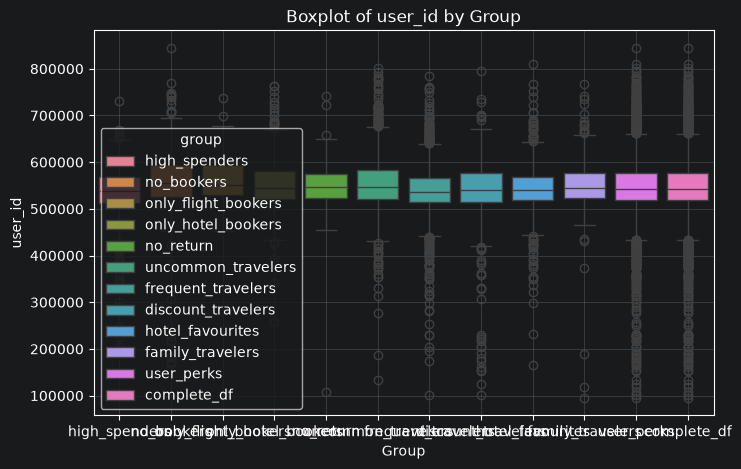

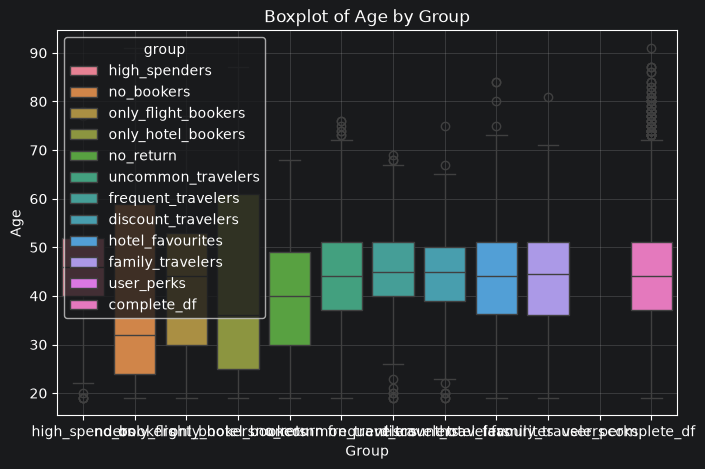

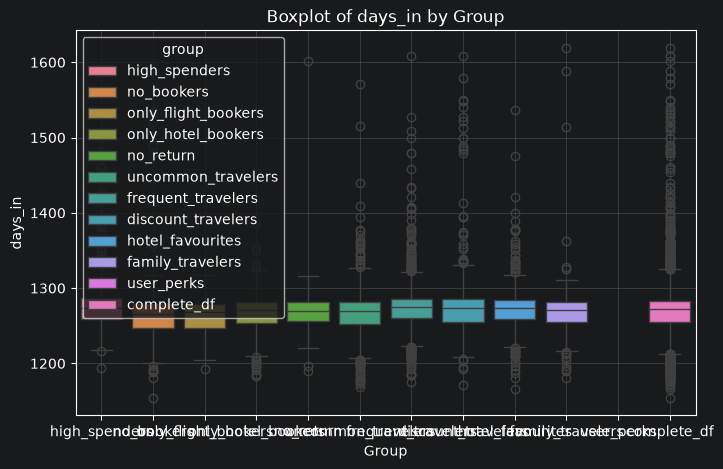

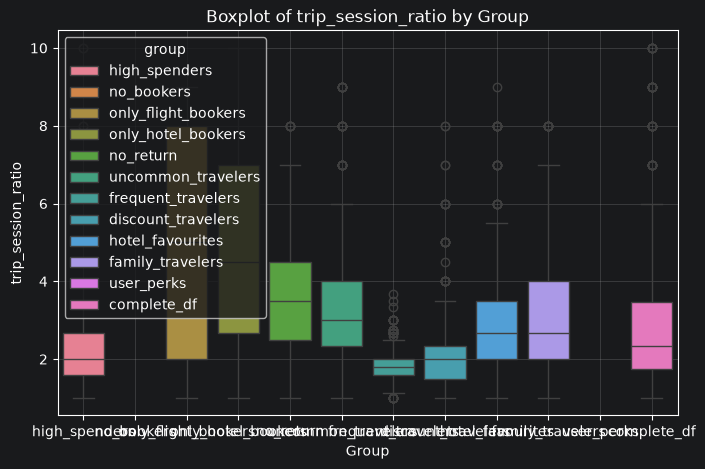

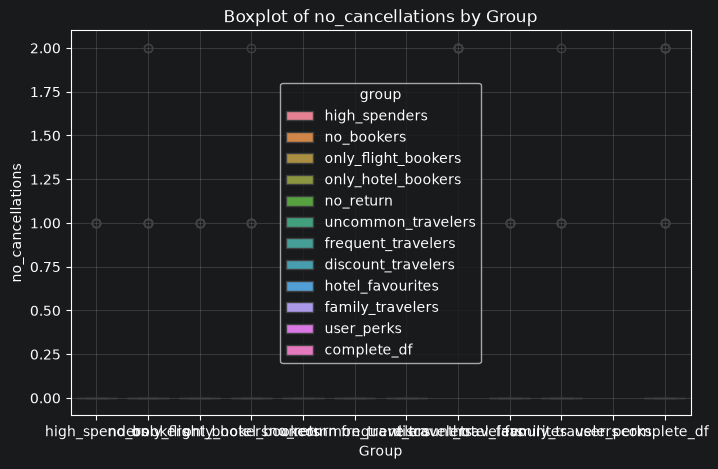

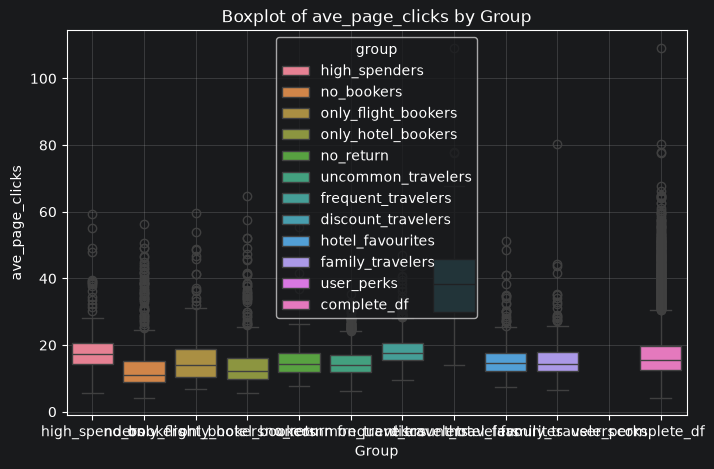

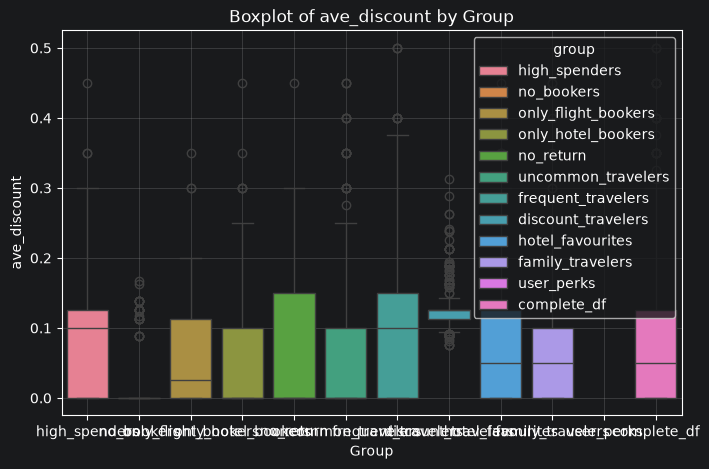

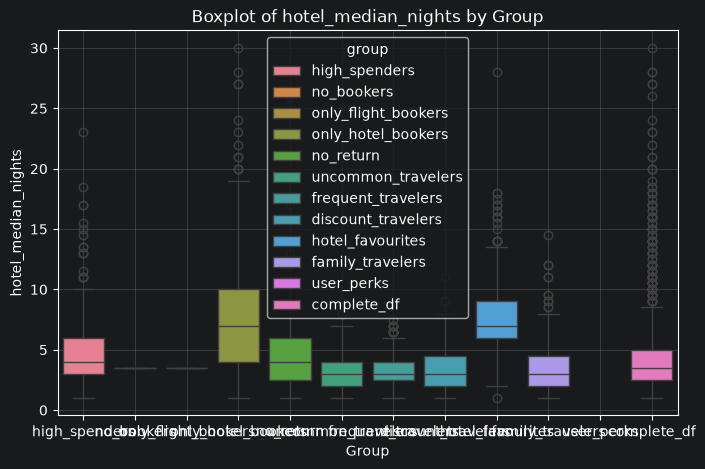

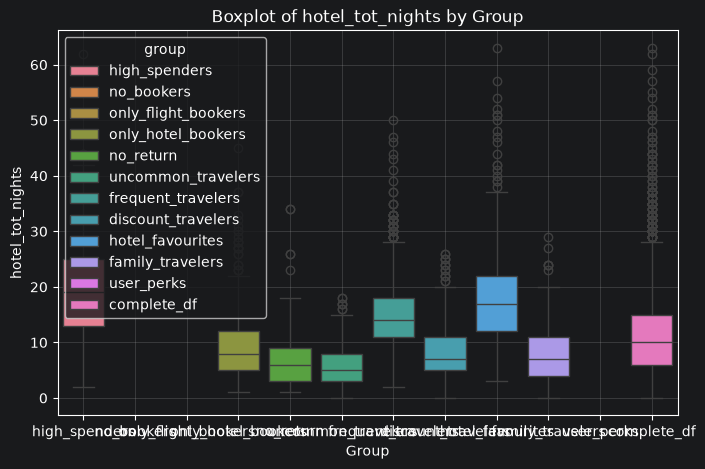

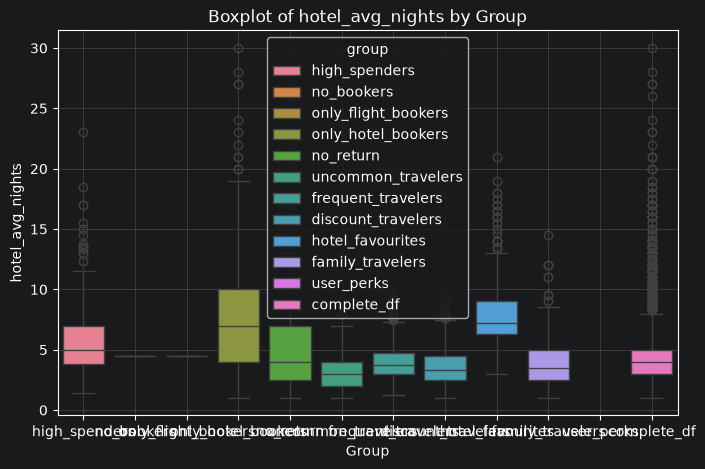

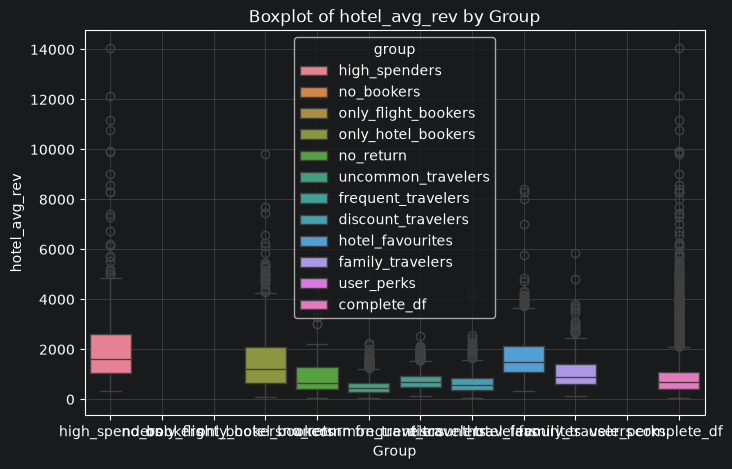

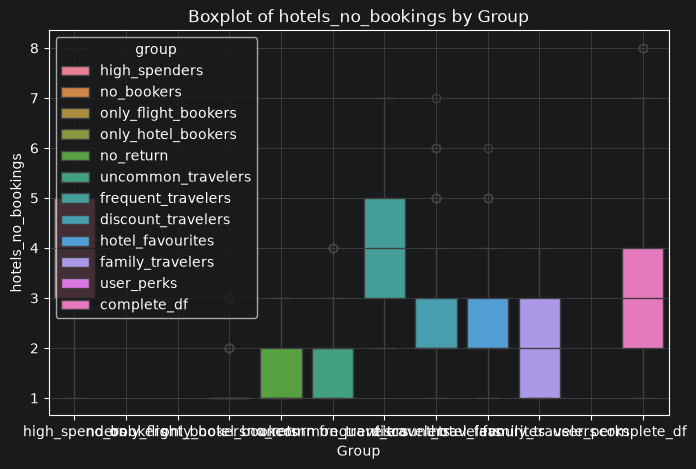

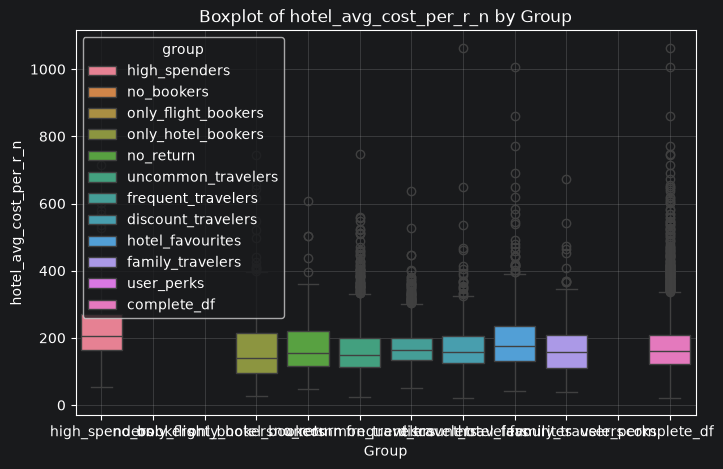

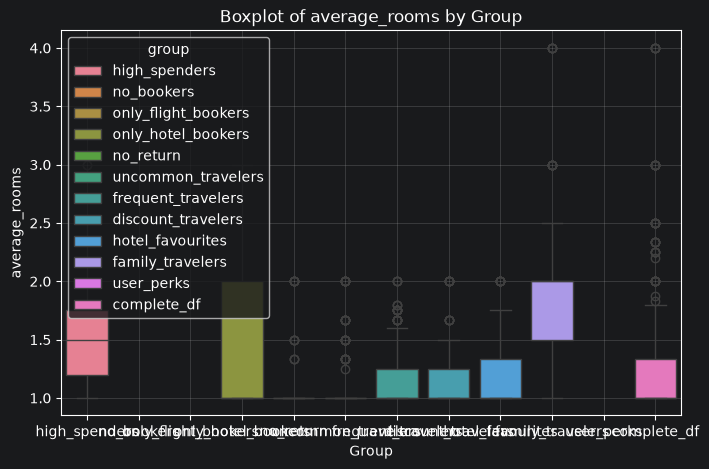

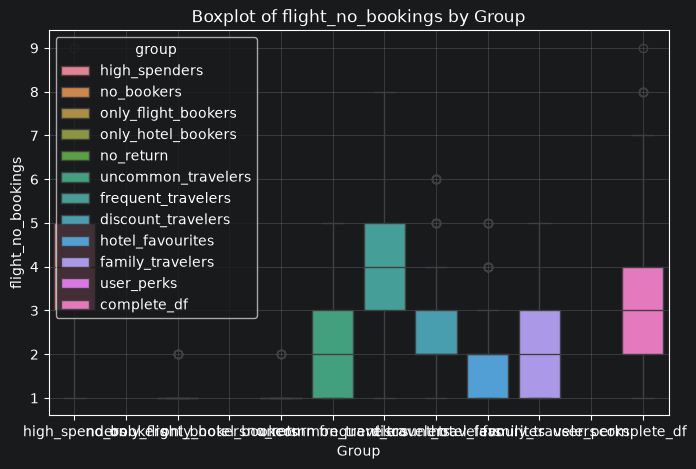

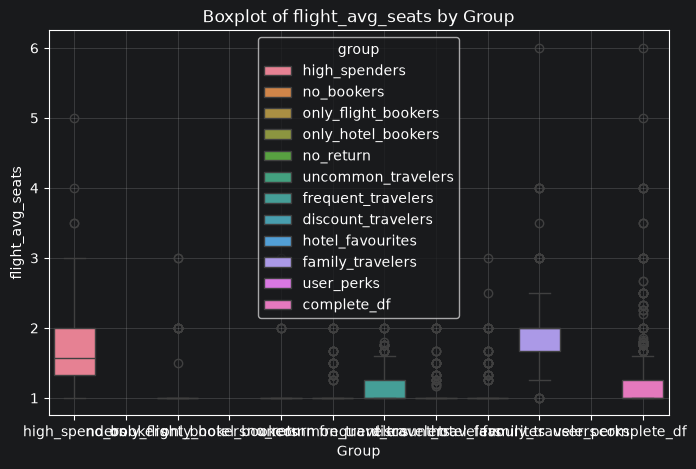

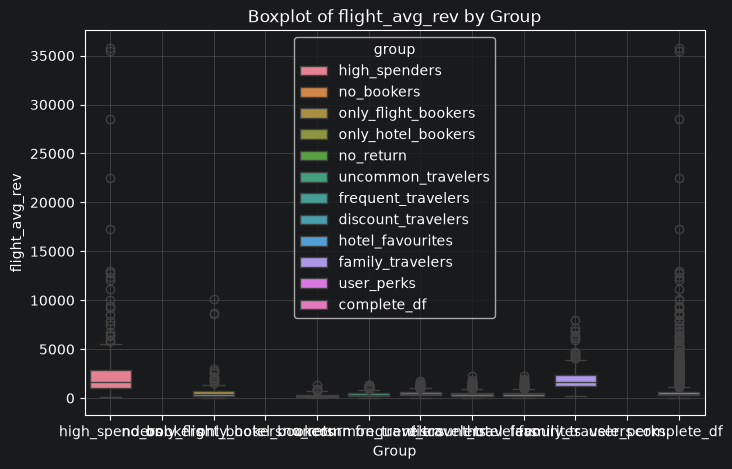

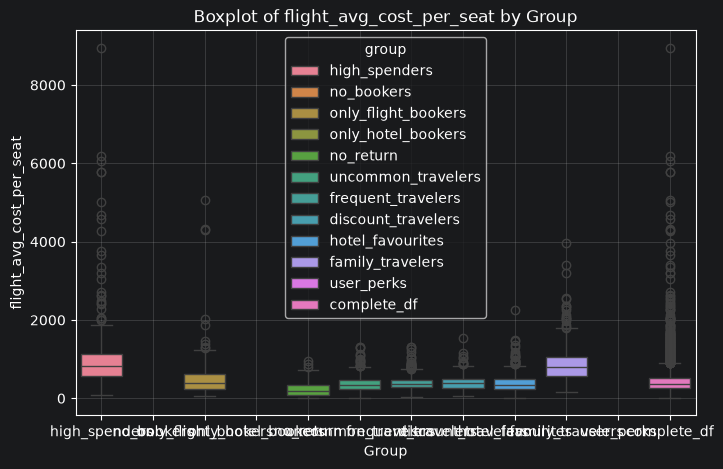

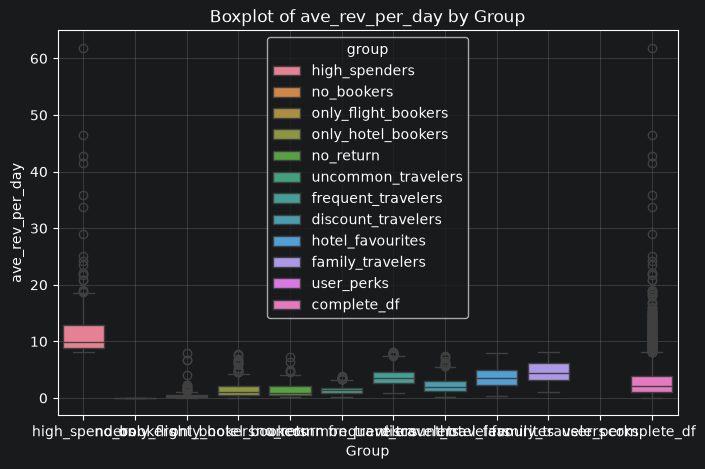

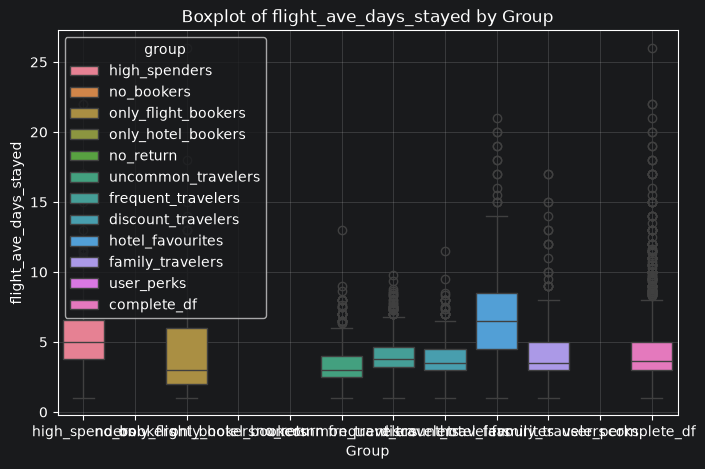

In [22]:
# Get numerical columns (excluding 'group' if it's categorical)
num_cols = df.select_dtypes(include=['float64', 'int64']).columns.tolist()

# Loop through each numerical column
for col in num_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df, x='group', y=col, hue='group', legend=True)
    plt.title(f'Boxplot of {col} by Group')
    plt.xlabel('Group')
    plt.ylabel(col)
    plt.grid(True, alpha=0.3)
    plt.show()

only flight bookers
- long decision
- not many flights, single seats
- stays long
- budget

only hotel
- seldom trips
- all ages
- long decision
- many nights in 1-2 rooms
- budget

no return
- faster decision
- single -> 1 room /1 seat
- budget

not much to say about no bookers with the data
- all ages

In [23]:
df['group'].unique()

<StringArray>
[      'high_spenders',          'no_bookers', 'only_flight_bookers',
  'only_hotel_bookers',           'no_return',  'uncommon_travelers',
  'frequent_travelers',  'discount_travelers',    'hotel_favourites',
    'family_travelers',          'user_perks',         'complete_df']
Length: 12, dtype: str

In [24]:
perk_dict = {
    'high_spenders': 'Exclusive Fine Dinning',
    'no_bookers': 'Big Discount',
    'only_flight_bookers': 'Loyalty Program',
    'only_hotel_bookers':'Loyalty Program',
    'no_return': 'Free Meal',
    'infrequent_travelers':'Free Meal',
    'frequent_travelers':'Loyalty Program',
    'discount_travelers':'Discount',
    'hotel_favourites': 'Free Spa',
    'family_travelers': 'Free Activity'
}

In [25]:
df['perk'].value_counts(normalize=True)

perk
Loyalty Program           0.358699
Free Meal                 0.295918
Free Spa                  0.093739
Big Discount              0.087859
Discount                  0.064684
Free Activity             0.053961
Exclusive Fine Dinning    0.045140
Name: proportion, dtype: float64

In [28]:
df.columns

Index(['user_id', 'gender', 'married', 'has_children', 'home_country', 'Age',
       'days_in', 'trip_session_ratio', 'no_cancellations', 'ave_page_clicks',
       'ave_discount', 'hotel_median_nights', 'hotel_tot_nights',
       'hotel_avg_nights', 'hotel_avg_rev', 'hotels_no_bookings',
       'hotel_avg_cost_per_r_n', 'average_rooms', 'flight_no_bookings',
       'flight_avg_seats', 'flight_avg_rev', 'flight_avg_cost_per_seat',
       'ave_rev_per_day', 'flight_ave_days_stayed', 'group', 'perk'],
      dtype='str')

In [37]:
# data for visualisations
result = df.groupby('group')[['Age','trip_session_ratio', 'no_cancellations','ave_discount','hotel_avg_nights','hotels_no_bookings','average_rooms', 'flight_no_bookings','flight_avg_seats','ave_rev_per_day']].mean()

(result.div(result.max(axis=0), axis=1)).T #normalize -> max value = 1

group,complete_df,discount_travelers,family_travelers,frequent_travelers,high_spenders,hotel_favourites,no_bookers,no_return,only_flight_bookers,only_hotel_bookers,uncommon_travelers,user_perks
Age,0.963680,0.964967,0.954951,1.000000,0.999877,0.963062,0.881509,0.881007,0.936708,0.929937,0.961468,NaN
trip_session_ratio,0.593941,0.449420,0.653331,0.394540,0.471539,0.620067,NaN,0.815595,1.000000,0.971380,0.704072,NaN
no_cancellations,0.102360,1.000000,0.067969,0.005998,0.055398,0.033790,0.168875,0.101465,0.174326,0.113706,0.002331,NaN
ave_discount,0.563434,1.000000,0.509471,0.759530,0.678921,0.582925,0.165165,0.583201,0.479613,0.434306,0.415289,NaN
hotel_avg_nights,0.557072,0.454437,0.491657,0.493369,0.730950,1.000000,0.557072,0.651786,0.557072,0.965878,0.386475,NaN
hotels_no_bookings,0.675281,0.601765,0.518117,1.000000,0.931437,0.594654,NaN,0.373737,NaN,0.311096,0.484580,NaN
average_rooms,0.648564,0.613272,1.000000,0.622088,0.837423,0.630460,NaN,0.635317,NaN,0.718485,0.576794,NaN
flight_no_bookings,0.694474,0.607439,0.525290,1.000000,0.958411,0.500328,NaN,0.284367,0.287392,NaN,0.510058,NaN
flight_avg_seats,0.603160,0.566350,1.000000,0.579905,0.854113,0.559942,NaN,0.571105,0.630389,NaN,0.534857,NaN
ave_rev_per_day,0.239990,0.183214,0.386262,0.316652,1.000000,0.315787,0.000000,0.132741,0.064411,0.133864,0.117302,NaN


In [26]:
user_groups = user_features[["user_id", "group"]]
user_groups["perk"] = user_groups["group"].map(perk_dict)
user_groups.to_csv("groups_data/user_perks.csv", index=False)
df["perk"] = df["group"].map(perk_dict)
df.to_csv('groups_data/complete_df.csv', index=False)